In [43]:
import pandas as pd
import numpy as np

In [44]:
customers = pd.read_csv("Downloads/customers.csv")
articles = pd.read_csv("Downloads/articles.csv")
transactions = pd.read_csv("Downloads/transactions_train.csv")

print(customers.shape)
print(articles.shape)
print(transactions.shape)

(1371980, 7)
(105542, 25)
(31788324, 5)


In [45]:
customers.head()


,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [46]:
articles.head()


,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [48]:
customers.isnull().sum()

customer_id                    0
FN                        895050
Active                    907576
club_member_status          6062
fashion_news_frequency     16011
age                        15861
postal_code                    0
dtype: int64

In [49]:
articles.isnull().sum()

article_id                        0
product_code                      0
prod_name                         0
product_type_no                   0
product_type_name                 0
product_group_name                0
graphical_appearance_no           0
graphical_appearance_name         0
colour_group_code                 0
colour_group_name                 0
perceived_colour_value_id         0
perceived_colour_value_name       0
perceived_colour_master_id        0
perceived_colour_master_name      0
department_no                     0
department_name                   0
index_code                        0
index_name                        0
index_group_no                    0
index_group_name                  0
section_no                        0
section_name                      0
garment_group_no                  0
garment_group_name                0
detail_desc                     416
dtype: int64

In [51]:
customers.drop(columns=['FN'], inplace=True)
customers.drop(columns=["Active"], inplace=True)

customers["club_member_status"] = (
    customers["club_member_status"]
    .fillna("UNKNOWN"))

customers["fashion_news_frequency"] = (
    customers["fashion_news_frequency"]
    .fillna("NONE"))



<Axes: >

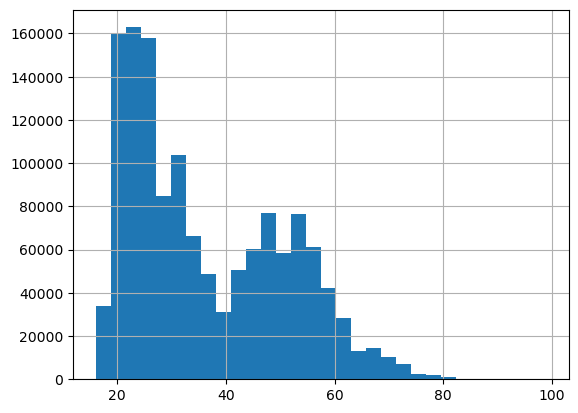

In [52]:
customers["age"].hist(bins=30)

In [53]:
customers["age"] = customers["age"].fillna(
    customers["age"].median()
)

In [54]:
customers["club_member_status"].value_counts(dropna=False)


club_member_status
ACTIVE        1272491
PRE-CREATE      92960
UNKNOWN          6062
LEFT CLUB         467
Name: count, dtype: int64

In [55]:
customers["fashion_news_frequency"].value_counts(dropna=False)


fashion_news_frequency
NONE         893722
Regularly    477416
Monthly         842
Name: count, dtype: int64

In [57]:
transactions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 31788324 entries, 0 to 31788323
Data columns (total 5 columns):
 #   Column            Dtype  
---  ------            -----  
 0   t_dat             object 
 1   customer_id       object 
 2   article_id        int64  
 3   price             float64
 4   sales_channel_id  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.2+ GB


In [58]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [59]:
transactions.isnull().sum()

t_dat               0
customer_id         0
article_id          0
price               0
sales_channel_id    0
dtype: int64

In [60]:
transactions["t_dat"]=pd.to_datetime(transactions["t_dat"])

In [65]:
print(transactions["t_dat"])

0          2018-09-20
1          2018-09-20
2          2018-09-20
3          2018-09-20
4          2018-09-20
              ...    
31788319   2020-09-22
31788320   2020-09-22
31788321   2020-09-22
31788322   2020-09-22
31788323   2020-09-22
Name: t_dat, Length: 31788324, dtype: datetime64[ns]


In [67]:
purchase_count = (
    transactions
    .groupby("customer_id")
    .size()
    .reset_index(name="purchase_count")
)

In [68]:
avg_spend =(
    transactions
    .groupby("customer_id")
    ["price"].mean()
    .reset_index(name ="avg_spend")
)

In [69]:
total_spend =(
    transactions
    .groupby("customer_id")
    ["price"].sum()
    .reset_index(name="total_spend")
)

In [76]:
last_purchase =(
    transactions
    .groupby("customer_id")
    ["t_dat"].max()
    .reset_index(name="last_purchase")
)



In [78]:
max_date = transactions["t_dat"].max()
last_purchase["days_since_last_purchase"] = (
    max_date - last_purchase["last_purchase"]
).dt.days

In [81]:
user_features=purchase_count.merge(
    avg_spend,
    on="customer_id"
)

In [84]:
user_features= user_features.merge(
    total_spend,
    on="customer_id"
)

In [85]:
user_features=user_features.merge(
    last_purchase[
   [ "customer_id",
    "days_since_last_purchase"]
    ],
    on="customer_id"
)

In [86]:
print(user_features.columns)

Index(['customer_id', 'purchase_count', 'avg_spend',
       'days_since_last_purchase_x', 'total_spend',
       'days_since_last_purchase_y'],
      dtype='object')


In [87]:
user_features.head()

,customer_id,purchase_count,avg_spend,days_since_last_purchase_x,total_spend,days_since_last_purchase_y
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,21,0.030904,17,0.648983,17
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,86,0.030255,76,2.601932,76
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,18,0.039154,7,0.704780,7
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2,0.030492,471,0.060983,471
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,13,0.036130,41,0.469695,41


In [89]:
(user_features["days_since_last_purchase_x"]==user_features["days_since_last_purchase_y"]).all()

np.True_

In [92]:
user_features.drop(
    columns=["days_since_last_purchase_y"],
    inplace=True
)

user_features.rename(
    columns={
        "days_since_last_purchase_x":
        "days_since_last_purchase"
    },
    inplace=True
    )

In [93]:
user_features.head()

,customer_id,purchase_count,avg_spend,days_since_last_purchase,total_spend
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,21,0.030904,17,0.648983
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,86,0.030255,76,2.601932
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,18,0.039154,7,0.704780
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,2,0.030492,471,0.060983
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,13,0.036130,41,0.469695


In [ ]:
club_member_status          6062
fashion_news_frequency     16011
age      

In [103]:
user_features = user_features.merge(
    customers[
   [ "club_member_status",
    "customer_id",
    "fashion_news_frequency",
    "age"]
    ],
    on="customer_id",
    how="left"
)

In [104]:
user_features.isnull().sum()

customer_id                 0
purchase_count              0
avg_spend                   0
days_since_last_purchase    0
total_spend                 0
club_member_status          0
fashion_news_frequency      0
age                         0
dtype: int64

In [106]:
user_features["age_group"] = pd.cut(
    user_features["age"],
    bins=[0,18,30,50,60],
    labels=["Teen",
            "Adults",
            "Middle Aged",
            "Senior Citizens"]
)

In [108]:
user_features["age_group"].value_counts()

age_group
Adults             600966
Middle Aged        440969
Senior Citizens    208544
Teen                33247
Name: count, dtype: int64

In [113]:
item_features = (
    transactions
    .groupby("article_id")
    .agg(
        purchase_count=("customer_id","count"),
        avg_price=("price","mean")
    )
        .reset_index()       
)

In [115]:
item_features = item_features.merge(
    articles[
    ["article_id",
     "product_type_name",
     "product_group_name",
     "garment_group_name",
     "colour_group_name"
    ]
    ],
    on="article_id",
    how="left"
)

In [116]:
item_features.head()

,article_id,purchase_count,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
0,108775015,10841,0.008142,Vest top,Garment Upper body,Jersey Basic,Black
1,108775044,7250,0.008114,Vest top,Garment Upper body,Jersey Basic,White
2,108775051,215,0.004980,Vest top,Garment Upper body,Jersey Basic,Off White
3,110065001,1044,0.020219,Bra,Underwear,"Under-, Nightwear",Black
4,110065002,539,0.018205,Bra,Underwear,"Under-, Nightwear",White


In [117]:
item_features.sort_values(
    by="purchase_count",
    ascending=False).head(10)
    

,article_id,purchase_count,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
53832,706016001,50287,0.032448,Trousers,Garment Lower body,Trousers,Black
53833,706016002,35043,0.032426,Trousers,Garment Lower body,Trousers,Light Blue
1711,372860001,31718,0.012958,Socks,Socks & Tights,Socks and Tights,Black
24808,610776002,30199,0.008083,T-shirt,Garment Upper body,Jersey Basic,Black
70124,759871002,26329,0.005605,Vest top,Garment Upper body,Jersey Basic,Black
3706,464297007,25025,0.016192,Underwear bottom,Underwear,"Under-, Nightwear",Black
1712,372860002,24458,0.012155,Socks,Socks & Tights,Socks and Tights,White
24807,610776001,22451,0.008079,T-shirt,Garment Upper body,Jersey Basic,White
2233,399223001,22236,0.030873,Trousers,Garment Lower body,Trousers Denim,Black
53834,706016003,21241,0.032588,Trousers,Garment Lower body,Trousers,Dark Blue


In [119]:
final_data = transactions.merge(
    user_features,
    on="customer_id",
    how="left"
)

final_data = final_data.merge(
    item_features,
    on="article_id",
    how="left")


In [120]:
final_data.head()

,t_dat,customer_id,article_id,price,sales_channel_id,purchase_count_x,avg_spend,days_since_last_purchase,total_spend,club_member_status,fashion_news_frequency,age,age_group,purchase_count_y,avg_price,product_type_name,product_group_name,garment_group_name,colour_group_name
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2,18,0.039154,7,0.70478,ACTIVE,NONE,24.0,Adults,633,0.045512,Underwear body,Underwear,"Under-, Nightwear",Black
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2,18,0.039154,7,0.70478,ACTIVE,NONE,24.0,Adults,434,0.024343,Bra,Underwear,"Under-, Nightwear",Light Pink
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2,120,0.031863,132,3.82361,ACTIVE,Regularly,32.0,Middle Aged,42,0.014834,Sweater,Garment Upper body,Knitwear,Pink
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2,120,0.031863,132,3.82361,ACTIVE,Regularly,32.0,Middle Aged,1836,0.021812,Sweater,Garment Upper body,Special Offers,Pink
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2,120,0.031863,132,3.82361,ACTIVE,Regularly,32.0,Middle Aged,1792,0.021569,Sweater,Garment Upper body,Special Offers,Dark Green


In [121]:
(final_data["purchase_count_x"]==final_data["purchase_count_y"]).all()

np.False_

In [123]:
user_features.to_csv(
    "user_features.csv",
    index=False
)

item_features.to_csv(
    "item_features.csv",
    index=False
)

final_data.to_csv(
    "final_data.csv",
    index=False
)